In [1]:
from collections import Counter
import cirq
import warnings
import sys

sys.path.append("../")
import resource_estimation as res

warnings.filterwarnings("ignore", category=FutureWarning)

# Overview
This notebook shows how to use `resource-superstaq` to estimate quantum resources from an arbitrary input circuit. The key metrics will be physical qubits, circuit runtime, and physical operation count. The basic flow is shown below:
- Have a `cirq` circuit
- Compile the circuit to the Clifford + Rz gateset
- Synthesize the Clifford + Rz circuit into a Clifford + T circuit using `pygridsynth`
- Choose an Architecture
    - Single Species with Movement (SSM)
    - Dual Species No Movement (DSNM)
    - Measure Zones Only(MZO)
    - Dual Species with Movement (DSM)
    - Superconducting (SSOQ)
- Choose a Layout
    - Generally `MovementLayout` for SSM or DSM
    - Generally `FactorySandwich` for DSNM or SSOQ
- Compile Clifford + T circuit to Primitives
    -  Primitives are Gate-like objects with simple physical decompositions
    -  This step includes routing for non-movement architectures
- Estimate Resources
    - Count gates by unrolling gate costs for primitives
    - Extract time by unrolling gate times for primitives


## Have a Circuit
For this example, we use a random unitary

In [2]:
qubits = 3
U = cirq.testing.random_unitary(dim=2**qubits, random_state=7)
circuit = cirq.Circuit(cirq.MatrixGate(U).on(*cirq.LineQubit.range(qubits)))
circuit

┌                                                                     ┐
      │ 0.385-0.087j -0.242-0.314j -0.212-0.333j  0.052-0.213j -0.124-0.348j│
      │  -0.062+0.076j  0.207+0.438j -0.318-0.045j                          │
      │ 0.232+0.025j  0.152+0.443j -0.087+0.353j  0.201-0.371j -0.004-0.037j│
      │  -0.145+0.237j -0.135-0.153j -0.437-0.323j                          │
      │ 0.126+0.149j  0.03 +0.25j   0.136+0.067j -0.383-0.487j  0.256-0.094j│
      │  -0.297-0.194j  0.28 +0.201j  0.413+0.045j                          │
      │-0.01 +0.348j -0.438+0.149j -0.048+0.187j -0.394+0.339j  0.259-0.163j│
0: ───│  -0.144+0.023j -0.256+0.088j -0.343+0.227j                          │───
      │-0.376+0.514j  0.308+0.218j -0.262-0.207j -0.119+0.015j -0.239+0.161j│
      │   0.156+0.172j  0.231+0.337j -0.133-0.069j                          │
      │ 0.191+0.111j -0.087-0.23j   0.052+0.309j -0.136+0.011j -0.591+0.344j│
      │  -0.323+0.072j -0.295+0.247j  0.202-0.087j                          │
      │ 0.061+0.24j  -0.16 +0.129j  0.546-0.34j   0.047-0.052j -0.335+0.113j│
      │  -0.144-0.314j  0.188-0.308j -0.315+0.054j                          │
      │-0.327-0.089j  0.223-0.225j  0.007+0.168j  0.256+0.128j  0.135+0.005j│
      │  -0.694+0.033j  0.287+0.068j -0.206+0.21j                           │
      └                                                                     ┘
      │
1: ───#2────────────────────────────────────────────────────────────────────────
      │
2: ───#3────────────────────────────────────────────────────────────────────────

## Compile to Clifford + Rz
Each application circuit generally does not come packaged neatly in a fault tolerant gateset, so we use an intermediate compilation step that converts the circuit to the Clifford + Rz gateset using local Cirq-based optimization (via `resource_estimation.cliff_rz.compile_cliff_rz`, which wraps `cirq.optimize_for_target_gateset`). This process can have the effect of magnifying inefficiencies that might have already existed in the input circuit. This is just a demonstration.

In [3]:
cliff_rz_circuit = res.cliff_rz.compile_cliff_rz(circuit)

In [4]:
print(f"Qubits: {cirq.num_qubits(cliff_rz_circuit)}")
print(f"Moments: {len(cliff_rz_circuit)}")

Qubits: 3
Moments: 96


In [5]:
print(f"Moments:{' ' * (10 - len(str(len(cliff_rz_circuit))))}{len(cliff_rz_circuit)}")
grouped_ops = Counter(
    str(op.gate) if op.gate not in cirq.GateFamily(cirq.Rz) else "Rz"
    for op in cliff_rz_circuit.all_operations()
)
for key, val in grouped_ops.items():
    if "Measurement" in key:
        key = "Measurement"
    print(f"{key}{' ' * (16 - len(key))}{val}")

Moments:        96
Rz              75
H               60
CNOT            20
Z               5
S               1


## Synthesize Circuit
We can use `pygridsynth` to compile the Rz gates generated in the previous step to strings of H, S, and T. The input parameter epsilon plays the main role in determining the length of these strings. In practice, we can choose this parameter based on the number Rz gates in the circuit and the program fidelity we would like. To keep things simple, we choose a program fidelity of 99%. The higher the requested fidelity, the more expensive the synthesis becomes.

In [6]:
eps = 1 - 0.99 ** (1 / grouped_ops["Rz"])
synthesized_circuit = res.clifford_t.compile_cirq_to_clifford_t(cliff_rz_circuit, eps=eps)

100%|██████████| 96/96 [00:00<00:00, 125.45it/s]


In [7]:
print(f"Moments:{' ' * 12}{len(synthesized_circuit)}")
grouped_ops = Counter(str(op.gate) for op in synthesized_circuit.all_operations())
for key, val in grouped_ops.items():
    if "Measurement" in key:
        key = "Measurement"
    print(f"{key}{' ' * (20 - len(key))}{val}")

Moments:            4571
X                   33
S                   1607
T                   3068
H                   3175
CNOT                20
Z                   5


## Choose an Architecture

In [8]:
ssm = res.architecture.DefaultMovement(
    d=11,  # Rotated Surface Code code distance
    idling=False,  # Include Syndrome Extraction on idling qubits in compiled circuit
    post_op_correction=True,  # Turn on or off Syndrome Extraction after transversal operations
    syndrome_rounds=1,  # Rounds of Syndrome Extraction after transversal operations
    cultivation_repetition=5,  # Expected repetitions of the cultivation circuit to get a successful T state
)

## Choose a Layout

In [9]:
layout = res.layout.MovementLayout(input_circuit=synthesized_circuit, num_t_factories=5)

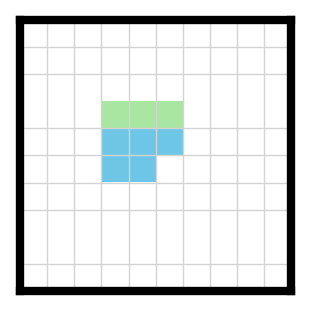

<Axes: >

In [10]:
layout.visualize_layout(grid_size=10)

## FT Compile

In [11]:
primitive_circuit = res.compile_ftqc.ft_compile(layout=layout, arc=ssm, verbose=True)

100%|██████████| 7908/7908 [00:00<00:00, 1162422.23it/s]


## Estimate Resources

In [12]:
estimator = res.estimate.ResourceEstimator(arc=ssm)
gate_cost = estimator.parallel_circuit_cost(primitive_circuit, pretty=True)
circuit_time = estimator.parallel_circuit_time(primitive_circuit)
physical_qubits = estimator.physical_qubits(primitive_circuit)

In [13]:
print("Gates")
for op, count in sorted(gate_cost.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count:.2e}")
print("*" * 33)
print("Metrics")
print(f"Time (μs){' ' * 16}{circuit_time:.2e}\nQubits{' ' * 19}{physical_qubits:.2e}")
print("*" * 33)

Gates
QubitPermutationGate     9.32e+05
CZ                       4.15e+05
PhasedXZGate             1.15e+05
ResetChannel             5.43e+04
MeasurementGate          5.12e+04
*********************************
Metrics
Time (μs)                5.40e+08
Qubits                   1.93e+03
*********************************
